In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("smartcart_customers.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


## Step 1 : Data Preprocessing 

## Handling Missing Values 

In [3]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [4]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## Feature Engineering

In [5]:
# Creating a new feature age from the given feature Birth Year
df["Age"] = 2026 - df["Year_Birth"]

In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [7]:
# creating new feauture customer_tenure menas how much day has been till the date of cutomer join using customer joining date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)
df["Customer_tenure"] = (df["Dt_Customer"].max() - df["Dt_Customer"]).dt.days

In [8]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [9]:
# Creating new feature Total_spending by adding all given spending on different product
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [11]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [13]:
df["Education"] = df["Education"].replace({

    "Basic" : "Undergraduate","2n Cycle" : "Undergraduate",
    "Graduation" : "Graduate",
    "Master" : "Postgraduate", "PhD" : "Postgraduate"
})

In [14]:
# Education 
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [15]:
# Maritial Status
df["Living_Status"] = df["Marital_Status"].replace(
    {
        "Married" : "Partner" , "Together" : "Partner",
        "Single" : "Alone" , "Divorced" : "Alone" , "Widow" : "Alone",
        "Absurd" : "Alone" ,"YOLO" : "Alone"
    }
)

In [16]:
df["Living_Status"].value_counts()

Living_Status
Partner    1444
Alone       796
Name: count, dtype: int64

In [20]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spend_col = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
cols_to_drop = cols + spend_col
df_cleaned  = df.drop(columns = cols_to_drop)

In [22]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure', 'Total_Spending',
       'Total_Children', 'Living_Status'],
      dtype='object')

# Outlier

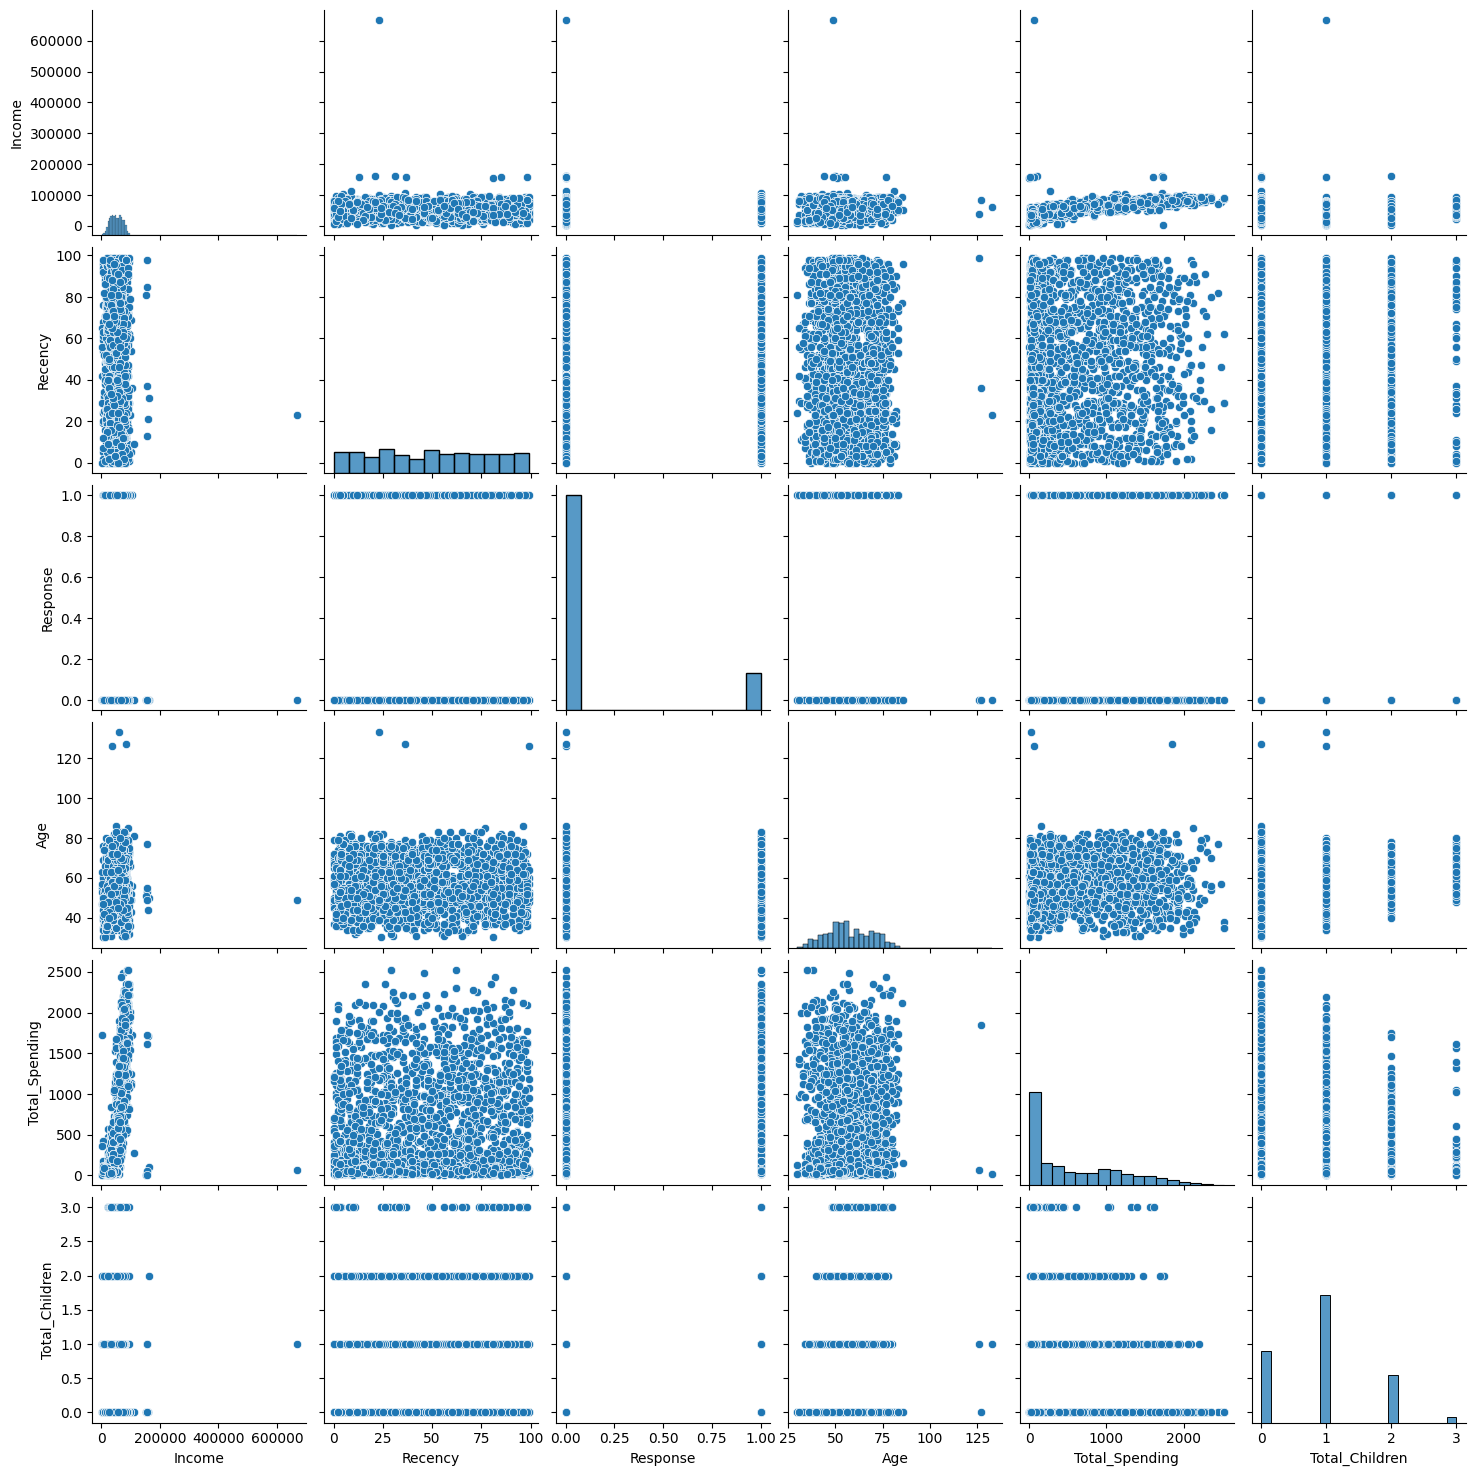

In [23]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"] 
sns.pairplot(df_cleaned [cols])

# Remove outliers 

In [24]:
print("Size of data with outlier",len(df_cleaned))
df_cleaned = df_cleaned[df_cleaned["Age"]<90]
df_cleaned = df_cleaned[df_cleaned["Income"]<600_000]
print("Size of data without outlier",len(df_cleaned))

Size of data with outlier 2240
Size of data without outlier 2236


# Correlation of features 

In [26]:
corr = df_cleaned.corr(numeric_only = True)

<Axes: >

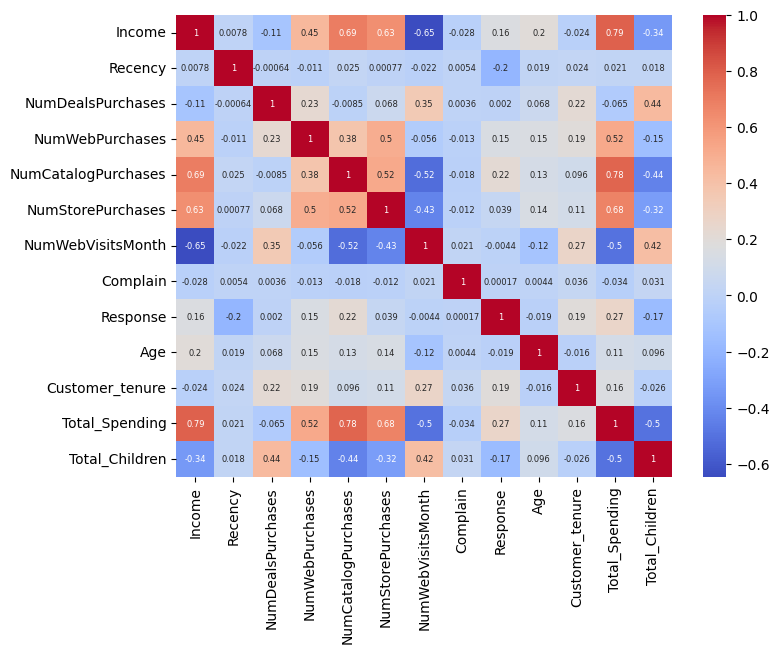

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot = True,
    annot_kws={"size" : 6},
    cmap="coolwarm"
)

# Feature Encoding 

In [30]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
cats_col = ["Education","Living_Status"]
en_cols = ohe.fit_transform(df_cleaned[cats_col])

In [33]:
en_df = pd.DataFrame(en_cols.toarray(),columns=ohe.get_feature_names_out(cats_col),index = df_cleaned.index)

In [35]:
df_encoded = pd.concat([df_cleaned.drop(columns = cats_col),en_df],axis = 1)
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_Status_Alone,Living_Status_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling 

In [40]:
from sklearn.preprocessing import StandardScaler 

x = df_encoded
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

# Visiualization 

In [44]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 3)
x_pca = pca.fit_transform(x_scaled)

In [45]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0, 'PC3')

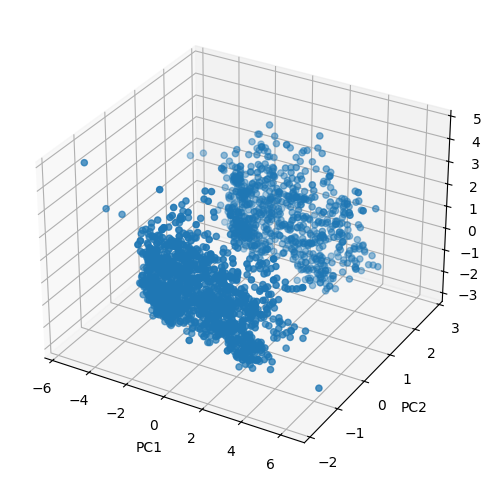

In [48]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection = "3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")


# Analyse K value 
## 1. Elbow Method

In [50]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters = k,random_state=42)
    labels = kmeans.fit_predict(x_pca)
    v = kmeans.inertia_
    wcss.append(v)

In [52]:
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow
optimal_k

np.int64(4)

# Clustering 

Text(0.5, 0, 'PC3')

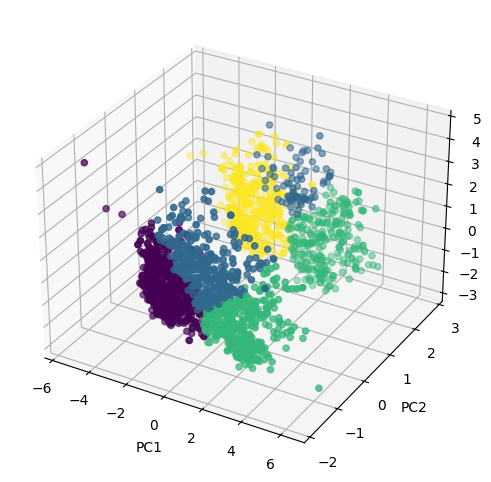

In [54]:
# KMeans 
kmeans = KMeans(n_clusters = 4,random_state =42)
label = kmeans.fit_predict(x_pca)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection = "3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=label)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")


Text(0.5, 0, 'PC3')

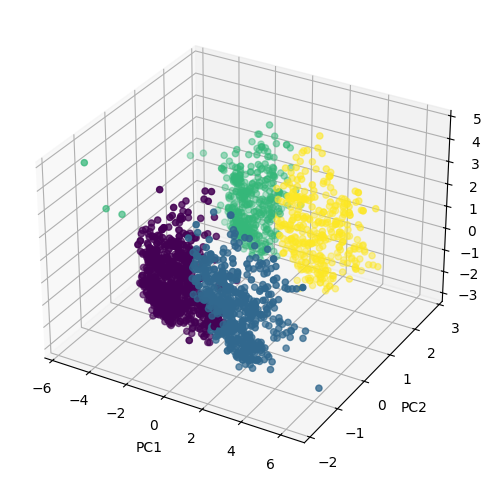

In [55]:
# Heirarchical Clustering 
from sklearn.cluster import AgglomerativeClustering 

agg_clf = AgglomerativeClustering(n_clusters = 4,linkage = "ward")
labels = agg_clf.fit_predict(x_pca)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection = "3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

# Characterization of Clusters
## what kind of info each cluster have 

In [64]:
df_cleaned.drop("Labels", axis=1)
df_cleaned["Clusters"] = labels

In [65]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure,Total_Spending,Total_Children,Living_Status,Labels,Clusters
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,3,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,1,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,0,0
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,0,0


<Axes: xlabel='Clusters', ylabel='count'>

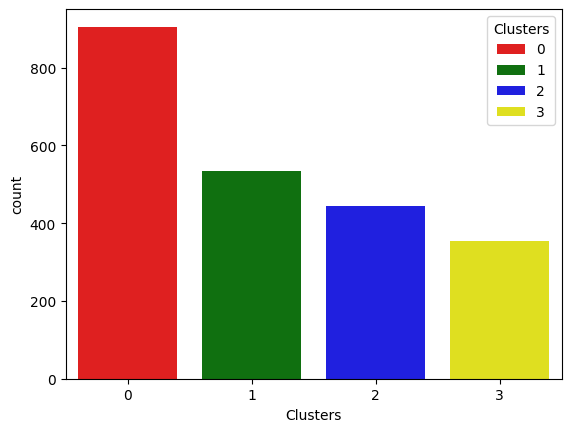

In [66]:
pal = ["red","green","blue","yellow"]
sns.countplot(x=df_cleaned["Clusters"],palette = pal , hue = df_cleaned["Clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

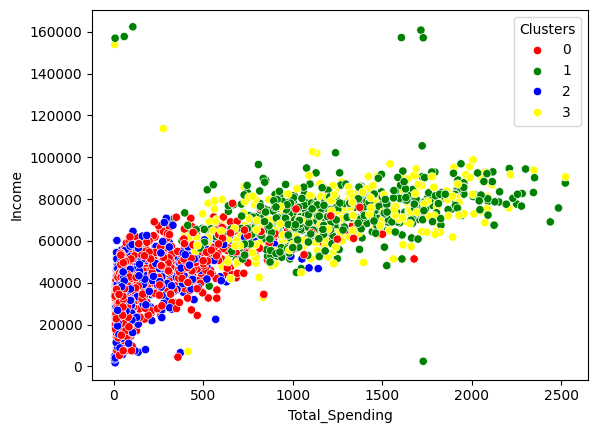

In [68]:
sns.scatterplot(x=df_cleaned["Total_Spending"],y=df_cleaned["Income"],hue=df_cleaned["Clusters"],palette=pal)

In [74]:
# from this we can find valuble data from the clusters 
x["Clusters"] =  labels
x.head()
cluster_summary = x.groupby("Clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
Clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_tenure  Total_Spending  \
Clusters